<a href="https://colab.research.google.com/github/maadishettyh13-dot/minor-project-spotify-/blob/main/minor_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_439/2719067976.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='playlist_genre', palette='viridis', order=df['playlist_genre'].value_counts().index)


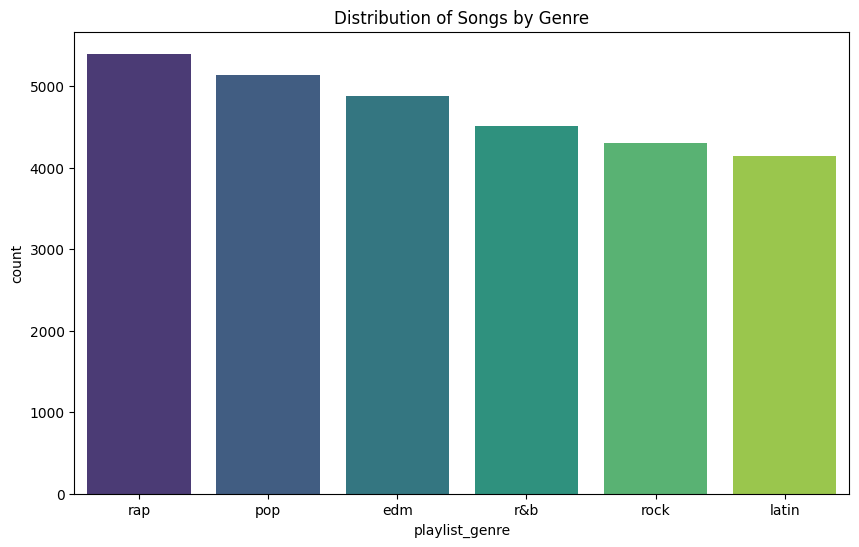

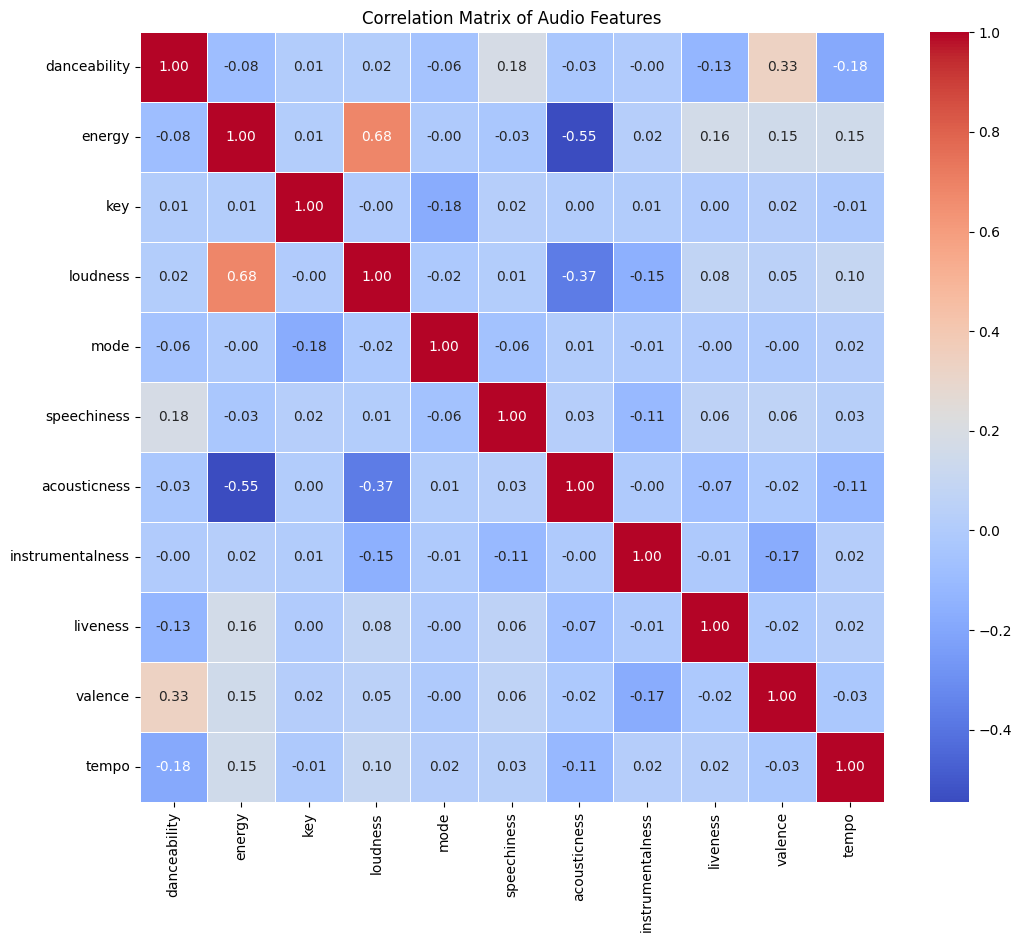

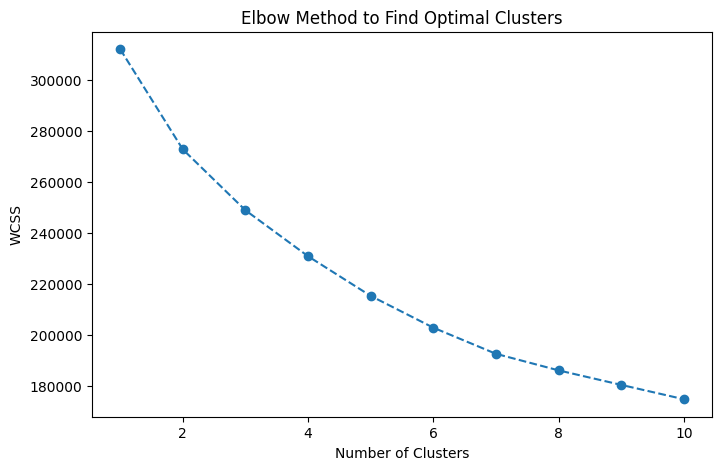

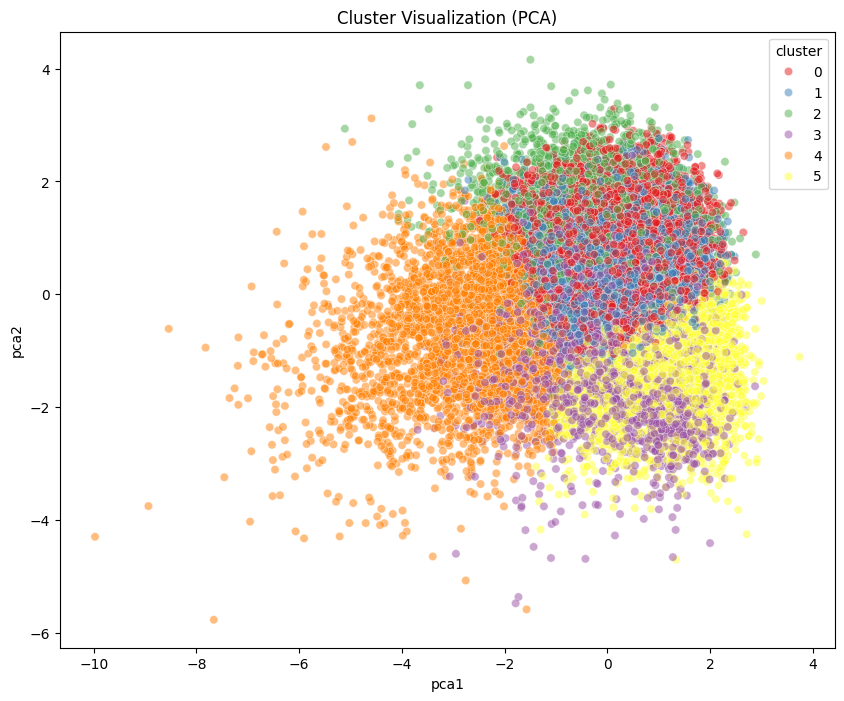

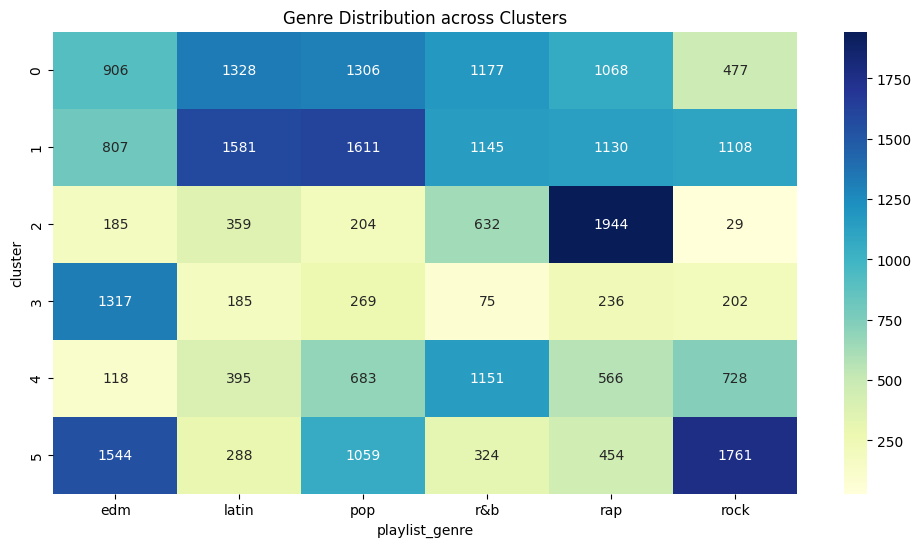

--- Final Result: Sample Recommendation ---
                      track_name      track_artist playlist_genre
10362                      M.I.A  Khea;Omar Varela            rap
21163            Spend The Night               Guy            r&b
14102  All Right Now - Remix '91              Free           rock
665                   Letting Go           Hogland            pop
1928                Hungover You        Hazey Eyes            pop


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# ==========================================
# 1. LOAD DATASET
# ==========================================
# Ensure the file path matches your local environment
df = pd.read_csv('/content/upload_1cc29b48-7982-4cdb-a0c8-c647c3cd2aa1.csv')

# ==========================================
# 2. DATA PRE-PROCESSING
# ==========================================
# Remove duplicates and missing values
df = df.drop_duplicates(subset=['track_id'])
df = df.dropna().reset_index(drop=True)

# Select numerical features for segmentation
audio_features = [
    'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo'
]

# Standardize the features (Essential for K-Means)
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[audio_features])

# ==========================================
# 3. DATA ANALYSIS & VISUALIZATIONS
# ==========================================
# Plot 1: Genre Distribution
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='playlist_genre', palette='viridis', order=df['playlist_genre'].value_counts().index)
plt.title('Distribution of Songs by Genre')
plt.show()

# Plot 2: Correlation Matrix
plt.figure(figsize=(12, 10))
correlation = df[audio_features].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Audio Features')
plt.show()

# ==========================================
# 4. CLUSTERING MODEL
# ==========================================
# Finding Optimal K using the Elbow Method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method to Find Optimal Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

# Building Final Model (using k=6 to align with genres or based on elbow)
k_optimal = 6
kmeans = KMeans(n_clusters=k_optimal, init='k-means++', random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(df_scaled)

# ==========================================
# 5. ANALYSIS OF CLUSTERS
# ==========================================
# Plot 3: Cluster Visualization using PCA (Dimensionality Reduction)
pca = PCA(n_components=2)
pca_data = pca.fit_transform(df_scaled)
df['pca1'], df['pca2'] = pca_data[:, 0], pca_data[:, 1]

plt.figure(figsize=(10, 8))
sns.scatterplot(data=df, x='pca1', y='pca2', hue='cluster', palette='Set1', alpha=0.5)
plt.title('Cluster Visualization (PCA)')
plt.show()

# Plot 4: Playlist Genre vs Clusters (Heatmap)
cluster_genre_dist = pd.crosstab(df['cluster'], df['playlist_genre'])
plt.figure(figsize=(12, 6))
sns.heatmap(cluster_genre_dist, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Genre Distribution across Clusters')
plt.show()

# ==========================================
# 6. FINAL RECOMMENDATION LOGIC
# ==========================================
def recommend_songs(song_name, num_recommendations=5):
    """Recommends songs from the same cluster."""
    if song_name not in df['track_name'].values:
        return "Song not found in dataset."

    # Get the cluster of the input song
    target_cluster = df[df['track_name'] == song_name]['cluster'].values[0]

    # Filter songs in the same cluster
    recommendations = df[df['cluster'] == target_cluster].sample(num_recommendations)
    return recommendations[['track_name', 'track_artist', 'playlist_genre']]

# Example Result
print("--- Final Result: Sample Recommendation ---")
print(recommend_songs(df['track_name'].iloc[0]))